In [5]:
# Import necessary libraries
import
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import numpy as np

In [6]:
# a) Define variables used in V:
phi = var(r'φ') # scalar field
k = 1
V0 = var(r'V_0') 
alp = var(r'α')
M = var('M')
N = var('N')
beta = var('β') # coupling variable
alp = 4 

In [7]:
# Expression for V and dv/dphi
def V(M,phi):
    return (M^(4+alp))/phi^alp

def dVdphi(M,phi):
    return -alp*V(M,phi)/phi

In [47]:
# Cosmological parameters
h = 0.7
ohm_m = 0.31 # approximate fraction of matter today
Ho = 2.1332e-42*h*4.10677e-19 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho^2/(k^2)) # current critical energy density
A = 0.65 # scaling constant
M_val = (rho_c0*(8*pi)^(alp/2))^(1/(alp+4))*A # mass scale in IPL
show(M_val)
gam = 1
beta = 0
Ni = 0
#2.82046850896656e-121 *np.pi*np.pi/2.48

(1.10977135095917e-15)*pi^(1/4)

In [35]:
def CoupledSteinhardt(X,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    rho_m = rho_c0*ohm_m*(a*ai)^(-3)
    Vfunc = V(M_val,X[0])
    #Vfunc = V.subs(V0 == V_value,phi ==X[0])
    dVfunc = dVdphi(M_val,X[0])

    H2 = (rho_m + Vfunc)/(3-0.5*(X[1])^2)
    HdotH2 = -0.5*((X[1])^2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2- beta*rho_m/H2
    #show(x2prime)
    return [x1prime,x2prime]

[0,
 (9.20297124150835e-120)*pi^2/((7.66914270125696e-121)*pi^2 + 1.16579365037285e-121)]

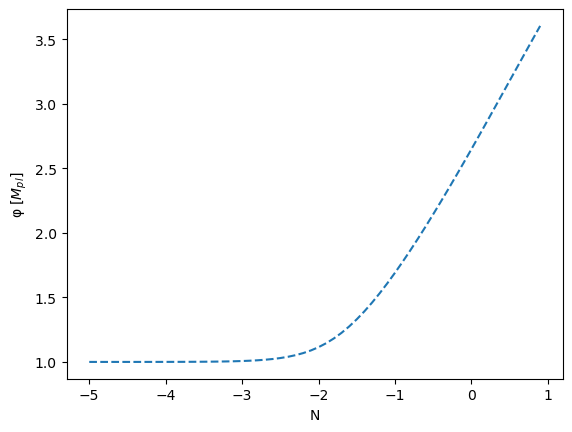

In [50]:
# Setting Suitable range of N values where N = 0 is today, negative N is past and positive N is future
Nrange = np.arange(-5,1,.1)
z_values = exp(-Nrange) # N = -ln(z+1)

# Testing output of CoupledSteinhardt function for N = 0:
Ni=0
show(CoupledSteinhardt([1,0],0))

# Testing CoupledSteinhardt function in odeint for our range of N values and then plotting solutions
sol = odeint(CoupledSteinhardt,[1,0],t=Nrange)
phi_sol = sol[:,0]
phi_prime = sol[:,1]
z_values = exp(-Nrange)
plt.xlabel("N")
plt.ylabel(r"φ $[M_{pl}]$")
plt.plot(Nrange,phi_sol,'--')

In [38]:
def other_parameters(fi,dfi,N):
    '''
    Function that calculates cosmological parameters using values of fi = φ and dfi = φ' for each value of N
    Explanation of all parameters calculated given in Key file
    '''
    a = exp(N) # N = ln(a)
    ai = exp(Ni) # Ensures rho_m has correct scaling today
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*(a*ai)^(-3)
    Pot = V(M_val,fi)
    H2 = (rho_m + Pot)/(3-1/2*dfi^2)
    rho_φ = 0.5*(dfi^2*H2) + Pot #Energy density of φ (ρ_φ)
    #ratio_rho = rho_φ/rho_m
    
    O_φ = ((k^2)/3)*(rho_φ/H2) # Ωφ
    O_m = 1-O_φ
    #ratio_O = O_φ/O_m
    
    Pφ = 0.5*(dfi^2*H2) - Pot
    Y_φ = (Pφ+rho_φ)/rho_φ
    w = Pφ/rho_φ #Equation of State wΦ
    weff = Pφ/(rho_φ + rho_m) #Equation of State wΦ
    return z,rho_φ,Pφ,O_φ,O_m,w,Y_φ,rho_m,weff

In [39]:
# Testing other_parameters function using solutions from test above
z,rho_s,P,O_Q,O_m,w,Y_Q,rho_m,weff = other_parameters(phi_sol,phi_prime,Nrange)
Z = z+1

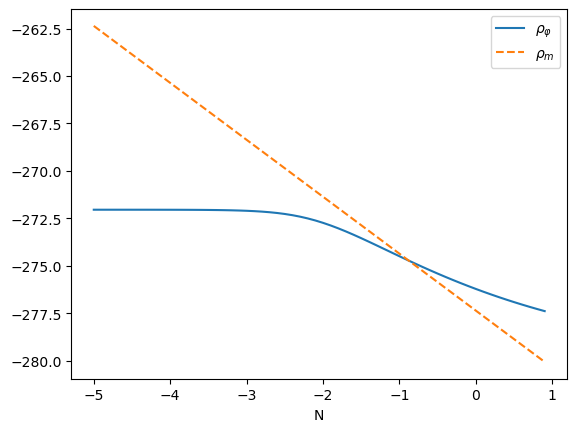

In [40]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs N - add or remove # to view plots

#plt.plot(Nrange,phi_sol, label  =r"φ")
#plt.plot(Nrange,phi_prime, label  =r"φ'")
plt.plot(Nrange,log(rho_s),label=r"$ρ_φ$")
plt.plot(Nrange,log(rho_m),label=r"$ρ_m$",ls='--')
#plt.plot(Nrange,P,label=r"P_φ") 
#plt.plot(Nrange,O_Q,label=r"Ω_φ") 
#plt.plot(Nrange,w,label=r"ω") 
plt.xlabel("N")
#plt.xlim([-1,1])
plt.legend()
#plt.savefig(r"log of $ρ_φ$ and $ρ_m$ for Q = {}.png".format(np.round(Q,3))) 

This figure shows the evolution of $\rho_φ$ and the evolution of $\rho_m$ from N = -5 to N = 1. N = 0 is the present day and positive N values depict the future. This figure shows that matter was dominant and th

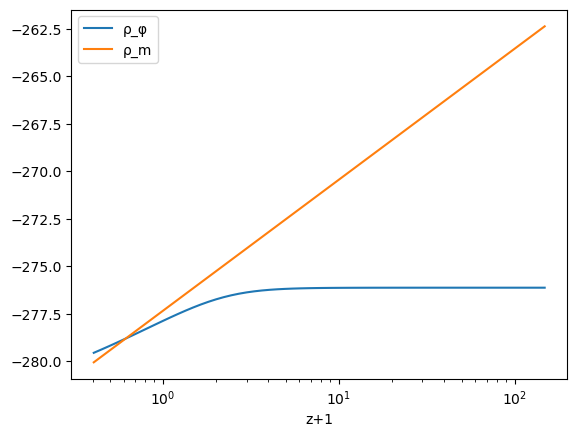

In [23]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs z+1

#plt.plot(Z,phi_sol, label  =r"φ")
#plt.plot(Z,phi_prime, label  =r"φ'")
plt.plot(Z,log(rho_s),label=r"ρ_φ")
plt.plot(Z,log(rho_m),label=r"ρ_m")
#show(Y_Q)
#plt.plot(Z,(Y_Q),label=r"γ_φ")
#plt.plot(Z,ratio_O,label = r"ratio_Ω")
#plt.plot(Z,P,label=r"P_φ")
#show(max(O_Q))
#show(max(Y_Q))
#plt.plot(Z,log(O_Q),label=r"Ω_φ") 
#plt.plot(Z,log(O_m),label=r"Ω_m")
#plt.plot(Z,O_m/O_Q,label=r"ratio_Ω")
#plt.plot(Z,w,label=r"ω") 
plt.xlabel("z+1")
plt.xscale('log')
plt.legend()

# Evolution of 6 cosmological parameters for different φ_i
In the following cell we simulate the evolution of cosmological parameters over a chosen range of $N$ while changing the initial value of $φ_i$. We then plot the evolution of the parameters as one figure. We only show the evolution of 6 cosmological parameters and these are: the scalar field, $\phi$, the potential of the scalar field, $V(\phi)$, the equation of state of the field, $\omega$, the energy densities of the scalar field and matter ($\rho_φ$,$\rho_m$) in logarithmic scales and the fractional densities of the scalar field and matter ($\Omega_φ$, $\Omega_m$). 

The numerical solutions of the cosmological parameters are generated inside the for loop using odeint as we did above. Except, this time we are changing the initial value of φ between 0.1 and 2 and generating φ and φ' for each value of φ_i. Once we have generated this data for the set range of N, we substitute φ and φ' into the other_parameters function to produce the remaining cosmological parameters. We do this for all values of φ_i  to test how φ_i influences the evolution of the cosmological parameters. For each φ_i value, each parameter is then assigned to a subplot in the function xaxis. 

The xaxis function takes four inputs: x, label, i, ls. x is the x-axis and so must be either Nrange or Z, where Z = z+1 and in logarithmic scales. label is where you enter the label for the x_axis. i is the same i that is in the for loop and so is the value that is changing which in this case is φ_i. ls is the linestyle of the plots. This is needed so that each value solution of φ is a different linestyle. 

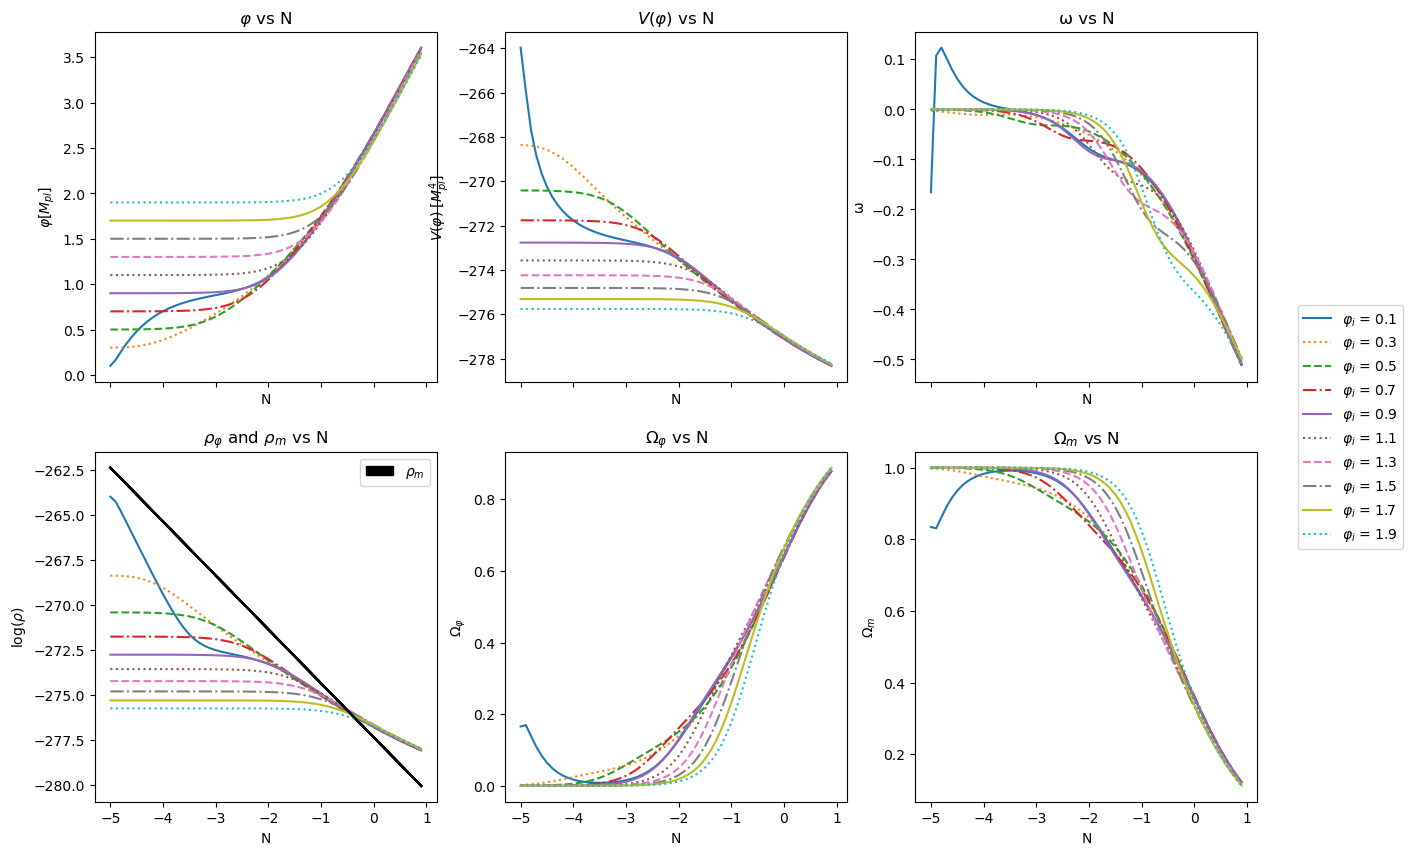

In [52]:
# Create N range
Nrange = np.arange(-5,1,.1)
Ni = Nrange[0]

# Create lists for legend and ω values as loop
beta_list = []
φ_list = []
w_list = []
rho_m_list = []

# Code to cyle through linestyles
from itertools import cycle 
StyleList = ['solid','dotted','dashed','dashdot']
lines = cycle(StyleList)

fig, axs = plt.subplots(2,3, figsize=(15, 10),sharex=True) # Create subplots


def xaxis(x,label,i,ls):
    '''
    Function that assigns cosmological parameters to certain subplot
    x = x_axis which can either be Nrange or Z
    label = for which x chosen, must type in either 'N' or 'z+1' for corresponding x
    i = value for φi which will be looped through/chosen in following code
    ls = parameter where you choose linestyle or call lines to cycle through linestyles
    '''
    #axs[0,0].set_yscale('log')
    axs[0,0].plot(x,solQ[:,0],label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[0,0].set(ylabel = r"$φ[M_{pl}]$", xlabel = "{}".format(label),title=r"$φ$ vs {}".format(label))
    if label == "z+1":
        axs[0,0].set_xscale('log')
        axs[0,0].xaxis.set_inverted(True)
    
    
    #axs[0,1].plot(x,solQ[:,1],label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    #axs[0,1].set(ylabel = r"$φ$'$[M_{pl}]$", xlabel = "{}".format(label),title=r"$φ$' vs {}".format(label))

    axs[0,1].plot(x,log(V(M_val,solQ[:,0])),label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    axs[0,1].set(ylabel = r"$V(φ)$ $[M_{pl}^4]$", xlabel = "{}".format(label),title=r"$V(φ)$ vs {}".format(label))
    #axs[0,1].legend()
    
    #axs[0,2].plot(x,P,label=r"$φ_i$ = {}".format(i))
    #axs[0,2].set(ylabel = r"P_φ", xlabel = "{}".format(label),title=r"$P_φ$ vs {}".format(label))
    #axs[0,2].legend()
    
    #axs[1,0].plot(x,rho, linestyle = "{}".format(ls))
    axs[1,0].plot(x,log(rho), linestyle = "{}".format(ls))
    axs[1,0].plot(x,log(rho_m),label=r"$\rho_m$",color='black')
    axs[1,0].set(ylabel = r"log($ρ$)", xlabel = "{}".format(label),title=r"$ρ_φ$ and $ρ_m$ vs {}".format(label))
    
    #rho_m_list += axs[1,0].plot(x,log(rho_m),label=r"$\rho_m$",color='black')
    #axs[1,0].set_xlim(0,0.5)
    
    axs[1,1].plot(x,O_Q,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[1,1].set(ylabel = r"$Ω_φ$", xlabel = "{}".format(label),title=r"$Ω_φ$ vs {}".format(label))
    #axs[1,1].set_xlim(-1,0)
    #axs[1,1].legend()
    
    axs[1,2].plot(x,O_m,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[1,2].set(ylabel = r"$Ω_m$", xlabel = "{}".format(label),title=r"$Ω_m$ vs {}".format(label))
    #axs[1,2].legend()

    axs[0,2].plot(x,weff,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    axs[0,2].set(ylabel = r"ω", xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    #axs[0,2].legend()

    #axs[2,1].plot(x,Y_Q,label=r"$φ_i$ = {}".format(i))
    #axs[2,1].set(ylabel = r"$γ_φ$", xlabel = "{}".format(label),title=r"$γ_φ$ vs {}".format(label))
    #axs[2,1].legend()

    #axs[2,2].plot(x,log(rho_m),label=r"$φ_i$ = {}".format(i))
    #axs[2,2].set(ylabel = r"$ρ_m$", xlabel = "{}".format(label),title=r"$ρ_m$ vs {}".format(label))
    
φ_values = np.arange(.1,2,.2) # These are different initial values of φ 
beta_values = np.arange(.5,2,.5) # These are different initial values of coupling constant β
for i in φ_values:
    if i==0:
        continue
    else:
        Ni = Nrange[0]
        Ni=0
        
        φ_list.append("$φ_i$ = {}".format(np.round(i,4)))
        solQ = odeint(CoupledSteinhardt,[i,0],t=Nrange)
        '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
        z,rho,P,O_Q,O_m,w,Y_Q,rho_m,weff = other_parameters(solQ[:,0],solQ[:,1],Nrange)
        
        w_list.append((i,round(max(w),3)))
        #show(round(max(w),3))
        Z = z+1
        xaxis(Nrange,"N",i,next(lines)) # Here is where you can alter whether to view graphs w.r.t to N or z+1

import matplotlib.patches as mpatches
black_patch = mpatches.Patch(color='black', label=r"$\rho_m$") # Adds extra legend to rho plot for rho_m
axs[1,0].legend(handles=[black_patch])

fig.legend(φ_list,loc='center right')
#fig.suptitle("Plots of cosmological parameters")
fig.savefig(r"Coupled Steinhardt with $\beta$ = {}, and alpha = {}.png".format(np.round(beta,3),alp))

In [49]:
# Maximum value of ω reached for each φi. 
show(w_list)

[(np.float64(0.1), 0.951),
 (np.float64(0.30000000000000004), -0.252),
 (np.float64(0.5000000000000001), -0.288),
 (np.float64(0.7000000000000001), -0.312),
 (np.float64(0.9000000000000001), -0.342),
 (np.float64(1.1000000000000003), -0.378),
 (np.float64(1.3000000000000003), -0.416),
 (np.float64(1.5000000000000004), -0.456),
 (np.float64(1.7000000000000004), -0.496),
 (np.float64(1.9000000000000004), -0.534)]